# HWK 5 --- DATA 201 --- Week 5 Assignment

**Name: Raul Miranda**
**Date: March 20, 2026**

## Resampling Methods with the Iris Dataset

In this assignment, we will explore **bootstrap resampling, jackknife
resampling, and permutation tests** using the **Iris dataset**.

The Iris dataset contains measurements of iris flowers from three
species:

-   *Setosa*
-   *Versicolor*
-   *Virginica*

Each flower has four measurements:

-   sepal length
-   sepal width
-   petal length
-   petal width

------------------------------------------------------------------------

### Load the Dataset

Use the following code to load the dataset.

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Tasks

1.  Print the **number of observations** in the dataset.
2.  Print the **column names**.
3.  Count how many observations exist for each **species**.

In [21]:
print(f"Number of observations: {len(iris)}")
print(f"Column names: {iris.columns.tolist()}")
print(iris['species'].value_counts())

Number of observations: 150
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Part 1 --- Bootstrap Resampling

We will estimate the **mean sepal length** using bootstrap resampling.

## Task 1 --- Basic Statistics

Compute the following statistics for **sepal length**:

-   mean
-   median
-   standard deviation


In [22]:
sepal_length_mean = iris['sepal_length'].mean()
sepal_length_median = iris['sepal_length'].median()
sepal_length_std = iris['sepal_length'].std()

print(f"Mean sepal length: {sepal_length_mean:.2f}")
print(f"Median sepal length: {sepal_length_median:.2f}")
print(f"Standard deviation of sepal length: {sepal_length_std:.2f}")

Mean sepal length: 5.84
Median sepal length: 5.80
Standard deviation of sepal length: 0.83


## Task 2 --- Bootstrap the Mean

Perform **5,000 bootstrap resamples**.

Procedure:

1.  Sample the dataset **with replacement**.
2.  Each sample must contain **150 observations**.
3.  Compute the **mean sepal length** for each resample.
4.  Store the results.

Plot the **distribution of bootstrap means**.

**Note on Efficiency**

While 5,000 iterations is manageable for 150 rows, consider the
computational cost if our dataset had **1 million rows**.
If your computer feels slow, try **1,000 iterations first**.

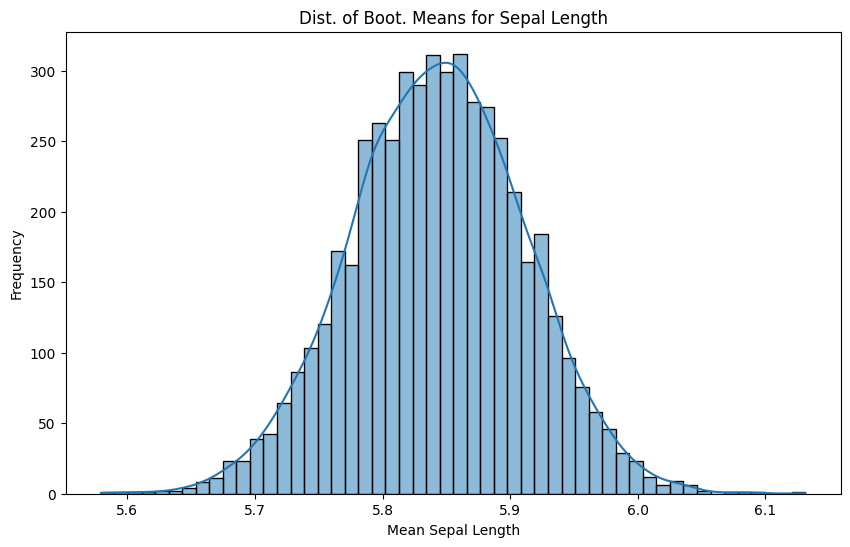

In [23]:
n_resamples = 5000
boot_means = []

for _ in range(n_resamples):
    # Sample this thing
    boot_sample = iris.sample(n=len(iris), replace=True)
    # Get mean sepal length for each resample
    each_mean = boot_sample['sepal_length'].mean()
    boot_means.append(each_mean)

# Plot the histogram of boot_means
plt.figure(figsize=(10, 6))
sns.histplot(boot_means, kde=True)
plt.title('Dist. of Boot. Means for Sepal Length')
plt.xlabel('Mean Sepal Length')
plt.ylabel('Frequency')
plt.show()

## Task 3 --- Confidence Interval

Using the bootstrap results, compute the **95% confidence interval**
using the percentile method:

CI = \[2.5%, 97.5%\]

Report:

-   Bootstrap mean
-   Lower bound
-   Upper bound

### Question

Why is it mathematically necessary to sample **with replacement** in
bootstrap resampling?

In [24]:
mean_boot_means = np.mean(boot_means)
lower_bound = np.percentile(boot_means, 2.5)
upper_bound = np.percentile(boot_means, 97.5)

print(f"Bootstrap Mean: {mean_boot_means:.2f}")
print(f"95% CI:")
print(f"  Lower Bound: {lower_bound:.2f}")
print(f"  Upper Bound: {upper_bound:.2f}")

Bootstrap Mean: 5.84
95% CI:
  Lower Bound: 5.71
  Upper Bound: 5.97


**Answer**: replacement is needed so that each sample has the same probability and is an independent draw from the population; then the computed statistics will approximate the actual population statistics; having replacement is necessary to ensure variability in the population and realistic estimation of confidence intervals. 

# Part 2 --- Jackknife Resampling

## Task 4 --- Jackknife the Mean

Create jackknife samples by removing **one observation at a time**.

Steps:

1.  For each observation i, remove it from the dataset.
2.  Compute the mean of the remaining observations.
3.  Store the result.

Plot the **distribution of jackknife means**.

**Visualization Tip**

Because you are removing only **one data point at a time**, the
resulting means will be extremely similar.
You may need to:

-   use a **large number of bins**, or
-   adjust `plt.xlim()`

to clearly see the variation.

### Question

If the dataset contains n observations, **exactly how many jackknife
samples** are created?


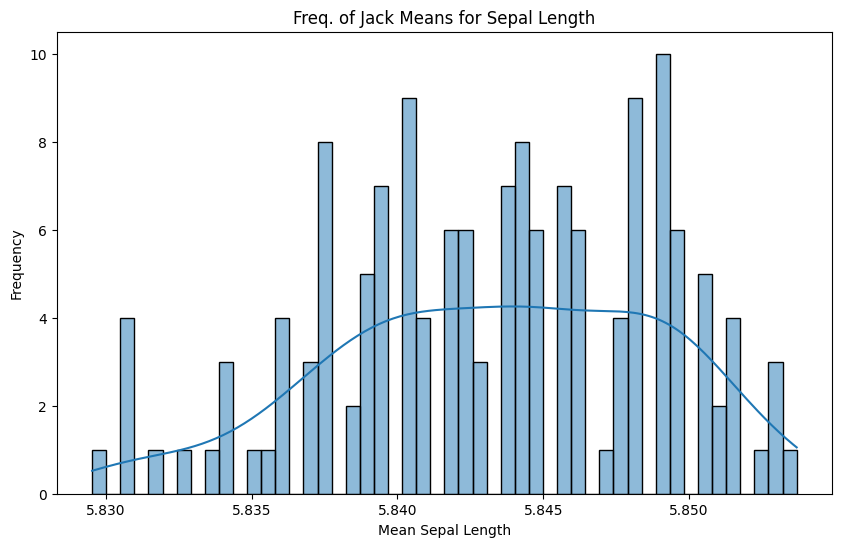

In [25]:
jack_means = []
n_obs = len(iris)

for i in range(n_obs):
    # jacknife
    jack_sample = iris.drop(index=i)
    # mean sepal length for the sample
    mean_jack_sample = jack_sample['sepal_length'].mean()
    jack_means.append(mean_jack_sample)

# Plot the distribution of jackknife means
plt.figure(figsize=(10, 6))
sns.histplot(jack_means, kde=True, bins=50) 
plt.title('Freq. of Jack Means for Sepal Length')
plt.xlabel('Mean Sepal Length')
plt.ylabel('Frequency')

plt.show()

**Answer**: n samples

# Part 3 --- Permutation Test

We will test whether **sepal length differs significantly between two
species**.

For this task, use:

-   **Versicolor**
-   **Virginica**

## Task 5 --- Observed Statistic

Compute the observed difference in means:

difference = mean(Versicolor) − mean(Virginica)


In [26]:
versicolor_sepal_length = iris[iris['species'] == 'versicolor']['sepal_length']
virginica_sepal_length = iris[iris['species'] == 'virginica']['sepal_length']

difference = versicolor_sepal_length.mean() - virginica_sepal_length.mean()

print(f"diff. in mean sepal length (Versicolor - Virginica): {difference:.2f}")

diff. in mean sepal length (Versicolor - Virginica): -0.65


## Task 6 --- Permutation Simulation

Run **1,000 permutations**.

Procedure:

1.  Combine the two species into one dataset.
2.  **Shuffle (permute) the labels**.
3.  Split the data back into two groups of the original sizes.
4.  Compute the difference in means.
5.  Store the result.

Plot the **permutation distribution**.


-0.21199999999999894 0.20000000000000018


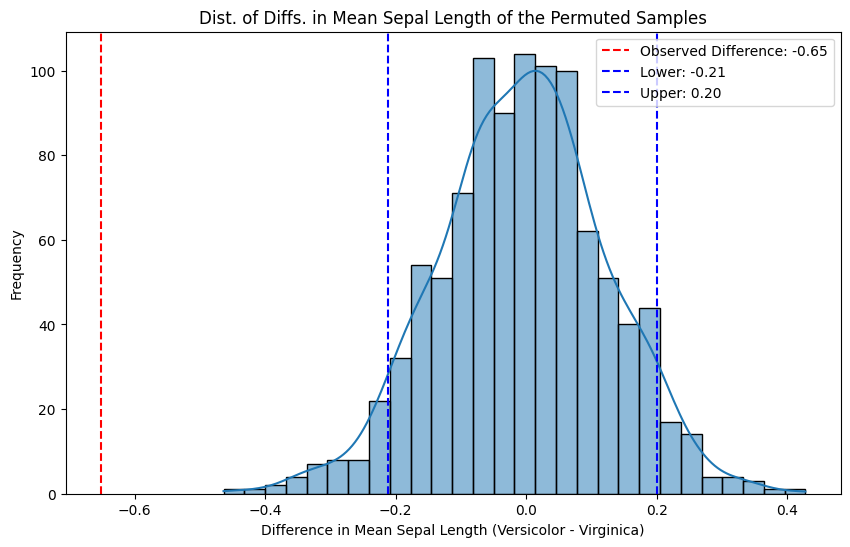

In [27]:
n_perms = 1000
perm_diffs = []

# Combind Versicolor and Virginica
comb_species = iris[iris['species'].isin(['versicolor', 'virginica'])]
orig_labels = comb_species['species'].values
orig_sepal_lengths = comb_species['sepal_length'].values

# sizes to be split
siz_versic = len(iris[iris['species'] == 'versicolor'])
siz_virgin = len(iris[iris['species'] == 'virginica'])

for i in range(n_perms):
    # permuted labels
    perm_labels = np.random.permutation(orig_labels)

    # create two groups of permuted labels
    perm_versic_sepal_length = orig_sepal_lengths[perm_labels == 'versicolor']
    perm_virgin_sepal_length = orig_sepal_lengths[perm_labels == 'virginica']

    # Compute the difference in means
    perm_diff = perm_versic_sepal_length.mean() - perm_virgin_sepal_length.mean()
    perm_diffs.append(perm_diff)
# as in the Demo in class, we'll calculate and plot the CI

#Use quantiles for define the 95% confidence interval.
upper = np.quantile(perm_diffs, 0.95)
lower = np.quantile(perm_diffs, 0.05)
print(lower, upper)


# Plot the permutation distributions
plt.figure(figsize=(10, 6))
sns.histplot(perm_diffs, kde=True)
plt.axvline(difference, color='red', linestyle='--', label=f'Observed Difference: {difference:.2f}')
plt.title('Dist. of Diffs. in Mean Sepal Length of the Permuted Samples')
plt.xlabel('Difference in Mean Sepal Length (Versicolor - Virginica)')
plt.ylabel('Frequency')
plt.axvline(x=lower, ymin=0, ymax=1, color='blue', linestyle='--', label=f'Lower: {lower:.2f}')
plt.axvline(x=upper, ymin=0, ymax=1, color='blue', linestyle='--', label=f'Upper: {upper:.2f}')
plt.legend()
plt.show()


## Task 7 --- p-value

Compute the p-value:

p = (number of simulated differences ≥ observed difference) / (total
simulations)

Interpret the result at α = 0.05.


In [28]:
n_perms = 1000
p_value = np.sum(np.abs(perm_diffs) >= np.abs(difference)) / n_perms
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"The p-value ({p_value:.4f}) is less than {alpha}. We reject the null hypothesis.")
    
else:
    print(f"The p-value ({p_value:.4f}) is greater than or equal to {alpha}. We fail to reject the null hypothesis.")
    

P-value: 0.0000
The p-value (0.0000) is less than 0.05. We reject the null hypothesis.




## Questions

1.  What is the **null hypothesis (H0)** in this specific test?
2.  What does the **permutation distribution** represent in terms of
    **random chance**?
3.  Based on your p-value, do you **reject** or **fail to reject** the
    null hypothesis?

    **Answers**
    1. H0 is that there is no significant difference between mean sepal lengths of Versicolor and Virginica species.

    2. The permutation distribution shows the distribution of the differences in mean sepal lengths between the 2 species if the null hypothesis H0 were true. That is, it shows all the differences that would be obtained by random chance, even if there were no real differences between the 2 species. The histogram above shows that observed (real) difference between sepal lengths falls outside the CI and outside the bell-shaped curve. That is, the difference is not due to random chance.

    3. Based on the p-value of 0, we reject the null hypothesis H0. That is, there is a statistically significant difference between the mean sepal lengths of Versicolor and Virginica species.

------------------------------------------------------------------------

# Submission

Submit a **Google Colab notebook** containing:

-   your code
-   plots
-   written answers

Then:

1.  Push your notebook to **GitHub** or simply upload if you do it in google colab.
2.  Submit the **GitHub link in MS Teams**.